In [11]:
# Shell vs Pebble Image Classification using CNN / MobileNetV2
# Kaggle-ready version
import os
from pathlib import Path
import random
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [12]:
# Check Kaggle input folders
for dirname, _, filenames in os.walk("/kaggle/input"):
    print(dirname, "->", len(filenames), "files")


/kaggle/input -> 0 files
/kaggle/input/datasets -> 0 files
/kaggle/input/datasets/vencerlanz09 -> 0 files
/kaggle/input/datasets/vencerlanz09/shells-or-pebbles-an-image-classification-dataset -> 0 files
/kaggle/input/datasets/vencerlanz09/shells-or-pebbles-an-image-classification-dataset/Shells -> 1541 files
/kaggle/input/datasets/vencerlanz09/shells-or-pebbles-an-image-classification-dataset/Pebbles -> 2743 files


In [13]:
# Helper functions are defined here instead of importing helper_functions.py

def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"{dirpath}: {len(filenames)} files")
        if dirnames:
            print("  folders:", dirnames)

def create_tensorboard_callback(dir_name, experiment_name):
    log_dir = Path(dir_name) / experiment_name
    return TensorBoard(log_dir=str(log_dir))

def plot_loss_curves(history):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    epochs = range(len(loss))

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, loss, label="training_loss")
    plt.plot(epochs, val_loss, label="validation_loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, accuracy, label="training_accuracy")
    plt.plot(epochs, val_accuracy, label="validation_accuracy")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


In [14]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

# Exact dataset path used by your original notebook
dataset = "/kaggle/input/datasets"

if not os.path.exists(dataset):
    raise FileNotFoundError(
        f"Dataset not found at {dataset}. "
        "In Kaggle, open Add Data and attach your Shells-or-Pebbles dataset."
    )

walk_through_dir(dataset)


/kaggle/input/datasets: 0 files
  folders: ['vencerlanz09']
/kaggle/input/datasets/vencerlanz09: 0 files
  folders: ['shells-or-pebbles-an-image-classification-dataset']
/kaggle/input/datasets/vencerlanz09/shells-or-pebbles-an-image-classification-dataset: 0 files
  folders: ['Shells', 'Pebbles']
/kaggle/input/datasets/vencerlanz09/shells-or-pebbles-an-image-classification-dataset/Shells: 1541 files
/kaggle/input/datasets/vencerlanz09/shells-or-pebbles-an-image-classification-dataset/Pebbles: 2743 files


In [15]:
# Build the image DataFrame
image_dir = Path(dataset)

extensions = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
filepaths = [p for p in image_dir.rglob("*") if p.suffix in extensions]

labels = [p.parent.name for p in filepaths]

image_df = pd.DataFrame({
    "Filepath": [str(p) for p in filepaths],
    "Label": labels
})

print("Total images:", len(image_df))
print("\nClass counts:")
print(image_df["Label"].value_counts())

display(image_df.head())


Total images: 4284

Class counts:
Label
Pebbles    2743
Shells     1541
Name: count, dtype: int64


,Filepath,Label
0,/kaggle/input/datasets/vencerlanz09/shells-or-...,Shells
1,/kaggle/input/datasets/vencerlanz09/shells-or-...,Shells
2,/kaggle/input/datasets/vencerlanz09/shells-or-...,Shells
3,/kaggle/input/datasets/vencerlanz09/shells-or-...,Shells
4,/kaggle/input/datasets/vencerlanz09/shells-or-...,Shells


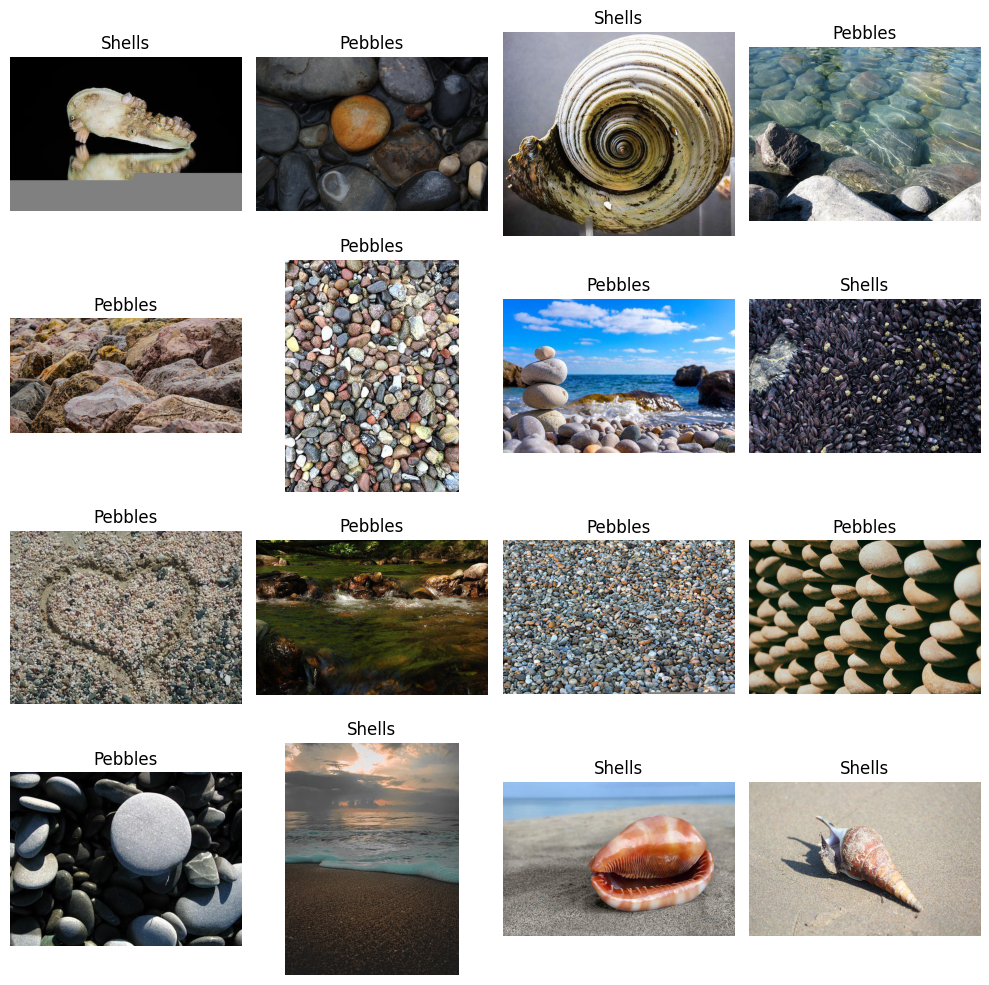

In [16]:
# Display sample images
random_index = np.random.choice(len(image_df), min(16, len(image_df)), replace=False)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < len(random_index):
        idx = random_index[i]
        ax.imshow(plt.imread(image_df.iloc[idx]["Filepath"]))
        ax.set_title(image_df.iloc[idx]["Label"])
    ax.axis("off")

plt.tight_layout()
plt.show()


In [17]:
# Train/test split
train_df, test_df = train_test_split(
    image_df,
    test_size=0.20,
    shuffle=True,
    random_state=42,
    stratify=image_df["Label"]
)

print("Training images:", len(train_df))
print("Test images:", len(test_df))


Training images: 3427
Test images: 857


In [18]:
# Image generators
train_generator = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.20
)

test_generator = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col="Filepath",
    y_col="Label",
    target_size=IMAGE_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    subset="training"
)

val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col="Filepath",
    y_col="Label",
    target_size=IMAGE_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    subset="validation"
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col="Filepath",
    y_col="Label",
    target_size=IMAGE_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class indices:", train_images.class_indices)


Found 2742 validated image filenames belonging to 2 classes.
Found 685 validated image filenames belonging to 2 classes.
Found 857 validated image filenames belonging to 2 classes.
Class indices: {'Pebbles': 0, 'Shells': 1}


In [21]:
# Load MobileNetV2
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=IMAGE_SIZE + (3,),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

pretrained_model.trainable = False

print("MobileNetV2 loaded successfully.")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded successfully.


In [22]:
# Build the classification model
inputs = pretrained_model.input
x = pretrained_model.output

x = Dense(128, activation="relu")(x)
x = Dropout(0.20)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.20)(x)

num_classes = len(train_images.class_indices)
outputs = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,438,722 (9.30 MB)

 Trainable params: 180,738 (706.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
# Callbacks
checkpoint_path = "/kaggle/working/shell_and_pebbles_classification_model.weights.h5"

checkpoint_callback = ModelCheckpoint(
    checkpoint_path,
    save_weights_only=True,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


In [31]:
# Train
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=10,
    callbacks=[
        early_stopping,
        create_tensorboard_callback("training_logs", "shell_and_pebble_classification"),
        checkpoint_callback
    ]
)


Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 937ms/step - accuracy: 0.7440 - loss: 0.5162
Epoch 1: val_accuracy improved from 0.77810 to 0.79854, saving model to /kaggle/working/shell_and_pebbles_classification_model.weights.h5

Epoch 1: finished saving model to /kaggle/working/shell_and_pebbles_classification_model.weights.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.7589 - loss: 0.5091 - val_accuracy: 0.7985 - val_loss: 0.4713
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.7769 - loss: 0.4856
Epoch 2: val_accuracy improved from 0.79854 to 0.80584, saving model to /kaggle/working/shell_and_pebbles_classification_model.weights.h5

Epoch 2: finished saving model to /kaggle/working/shell_and_pebbles_classification_model.weights.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 84s 975ms/step - accuracy: 0.7746 - loss: 0.4846 - val_accuracy: 0.8058 - val_loss: 0.4497
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.7778 - loss: 0.4822
Epoch 3: val_accuracy improved 

Test Loss: 0.37694
Test Accuracy: 83.66%


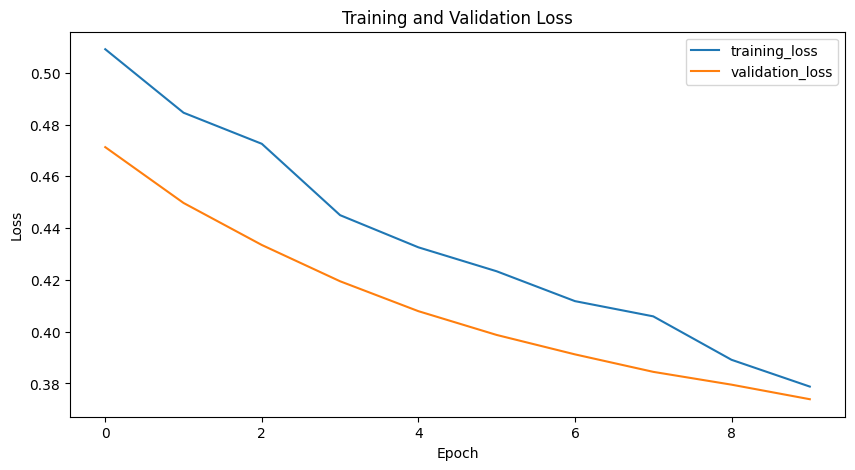

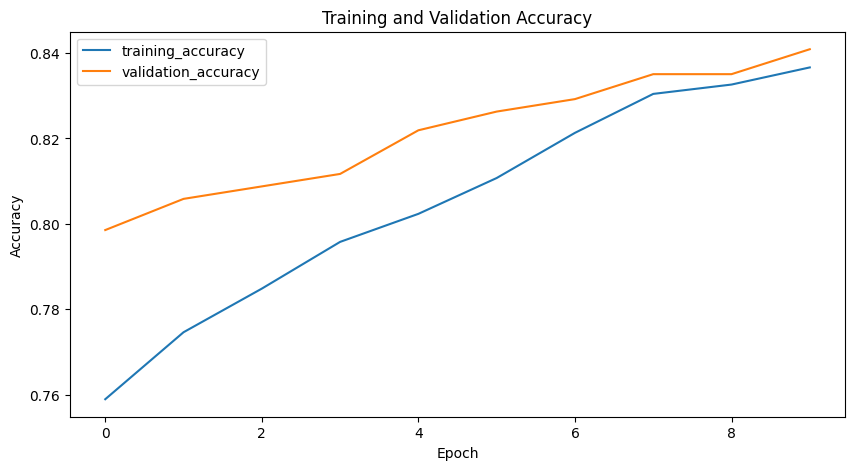

In [32]:
# Evaluate
results = model.evaluate(test_images, verbose=0)

print("Test Loss: {:.5f}".format(results[0]))
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

plot_loss_curves(history)


In [33]:
# Predictions
test_images.reset()
pred_probs = model.predict(test_images, verbose=1)
pred_ids = np.argmax(pred_probs, axis=1)

class_names = {v: k for k, v in train_images.class_indices.items()}
pred_labels = [class_names[i] for i in pred_ids]

print("First 10 predictions:", pred_labels[:10])


27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 808ms/step
First 10 predictions: ['Pebbles', 'Shells', 'Pebbles', 'Pebbles', 'Pebbles', 'Pebbles', 'Shells', 'Shells', 'Pebbles', 'Shells']


In [34]:
# Classification report
y_test = test_df["Label"].tolist()

print(classification_report(
    y_test,
    pred_labels,
    target_names=sorted(train_images.class_indices.keys())
))

report = classification_report(y_test, pred_labels, output_dict=True)
report_df = pd.DataFrame(report).transpose()
display(report_df)


              precision    recall  f1-score   support

     Pebbles       0.85      0.90      0.88       549
      Shells       0.80      0.73      0.76       308

    accuracy                           0.84       857
   macro avg       0.83      0.81      0.82       857
weighted avg       0.83      0.84      0.83       857



,precision,recall,f1-score,support
Pebbles,0.854419,0.897996,0.875666,549.000000
Shells,0.800000,0.727273,0.761905,308.000000
accuracy,0.836639,0.836639,0.836639,0.836639
macro avg,0.827210,0.812635,0.818785,857.000000
weighted avg,0.834861,0.836639,0.834781,857.000000


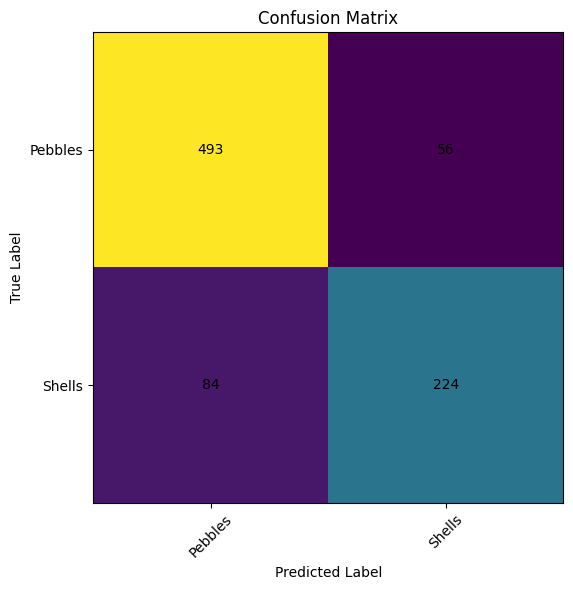

In [35]:
# Confusion matrix
cm = confusion_matrix(y_test, pred_labels, labels=sorted(train_images.class_indices.keys()))

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(class_names)), sorted(train_images.class_indices.keys()), rotation=45)
plt.yticks(range(len(class_names)), sorted(train_images.class_indices.keys()))

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


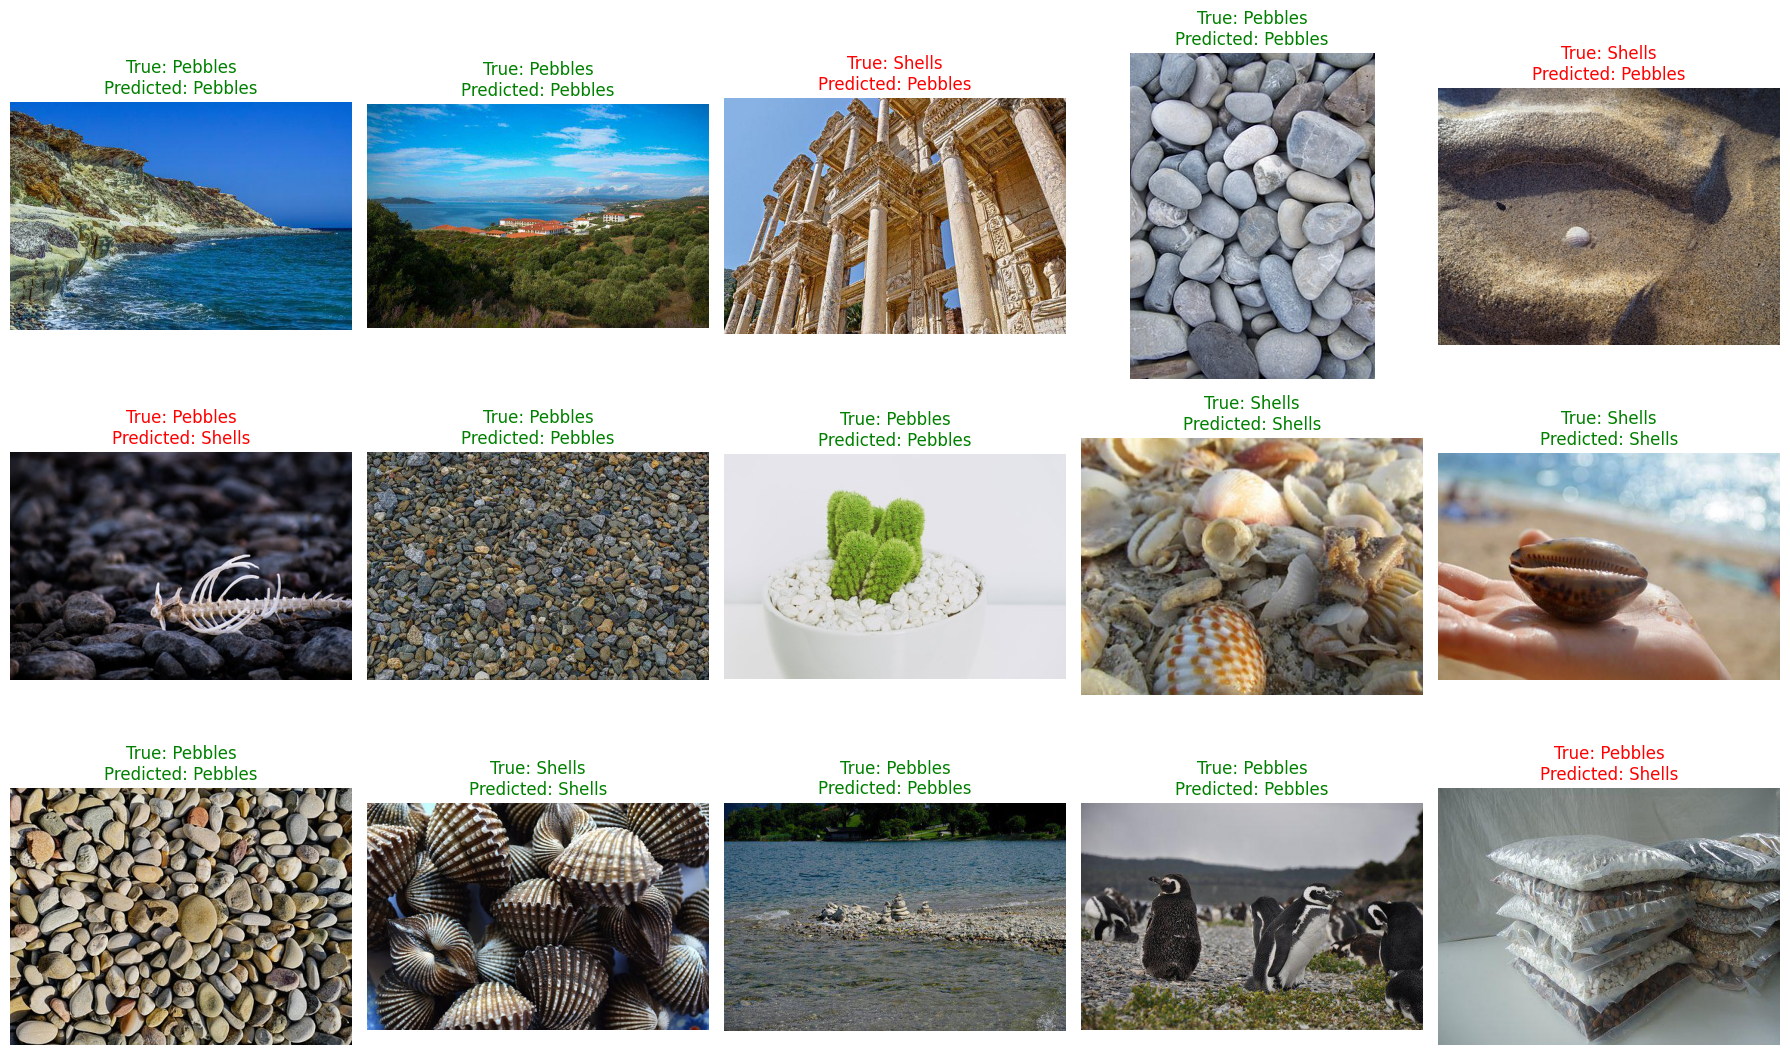

In [36]:
# Show random test predictions
random_index = np.random.choice(len(test_df), min(15, len(test_df)), replace=False)

fig, axes = plt.subplots(3, 5, figsize=(18, 11))

for i, ax in enumerate(axes.flat):
    if i < len(random_index):
        idx = random_index[i]
        true_label = test_df.iloc[idx]["Label"]
        predicted_label = pred_labels[idx]

        ax.imshow(plt.imread(test_df.iloc[idx]["Filepath"]))
        ax.set_title(
            f"True: {true_label}\nPredicted: {predicted_label}",
            color="green" if true_label == predicted_label else "red"
        )
    ax.axis("off")

plt.tight_layout()
plt.show()


In [42]:
# Optional: Grad-CAM visualization
# This version avoids tensorflow.keras.layers.experimental, which caused your earlier error.

def get_img_array(img_path, size):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    array = tf.keras.preprocessing.image.img_to_array(img)
    return np.expand_dims(array, axis=0)

def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name, pred_index=None):
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    max_value = tf.math.reduce_max(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (max_value + tf.keras.backend.epsilon())

    return heatmap.numpy()

def save_and_display_gradcam(img_path, heatmap, cam_path="/kaggle/working/cam.jpg", alpha=0.4):
    img = tf.keras.preprocessing.image.load_img(img_path)
    img = tf.keras.preprocessing.image.img_to_array(img)

    heatmap = np.uint8(255 * heatmap)
    jet = plt.cm.get_cmap("jet")
    jet_heatmap = jet(np.arange(256))[:, :3][heatmap]
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)
    superimposed_img.save(cam_path)

    return cam_path

# MobileNetV2's final convolution layer.
last_conv_layer_name = "Conv_1"


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_310']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipykernel_58/4053296448.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


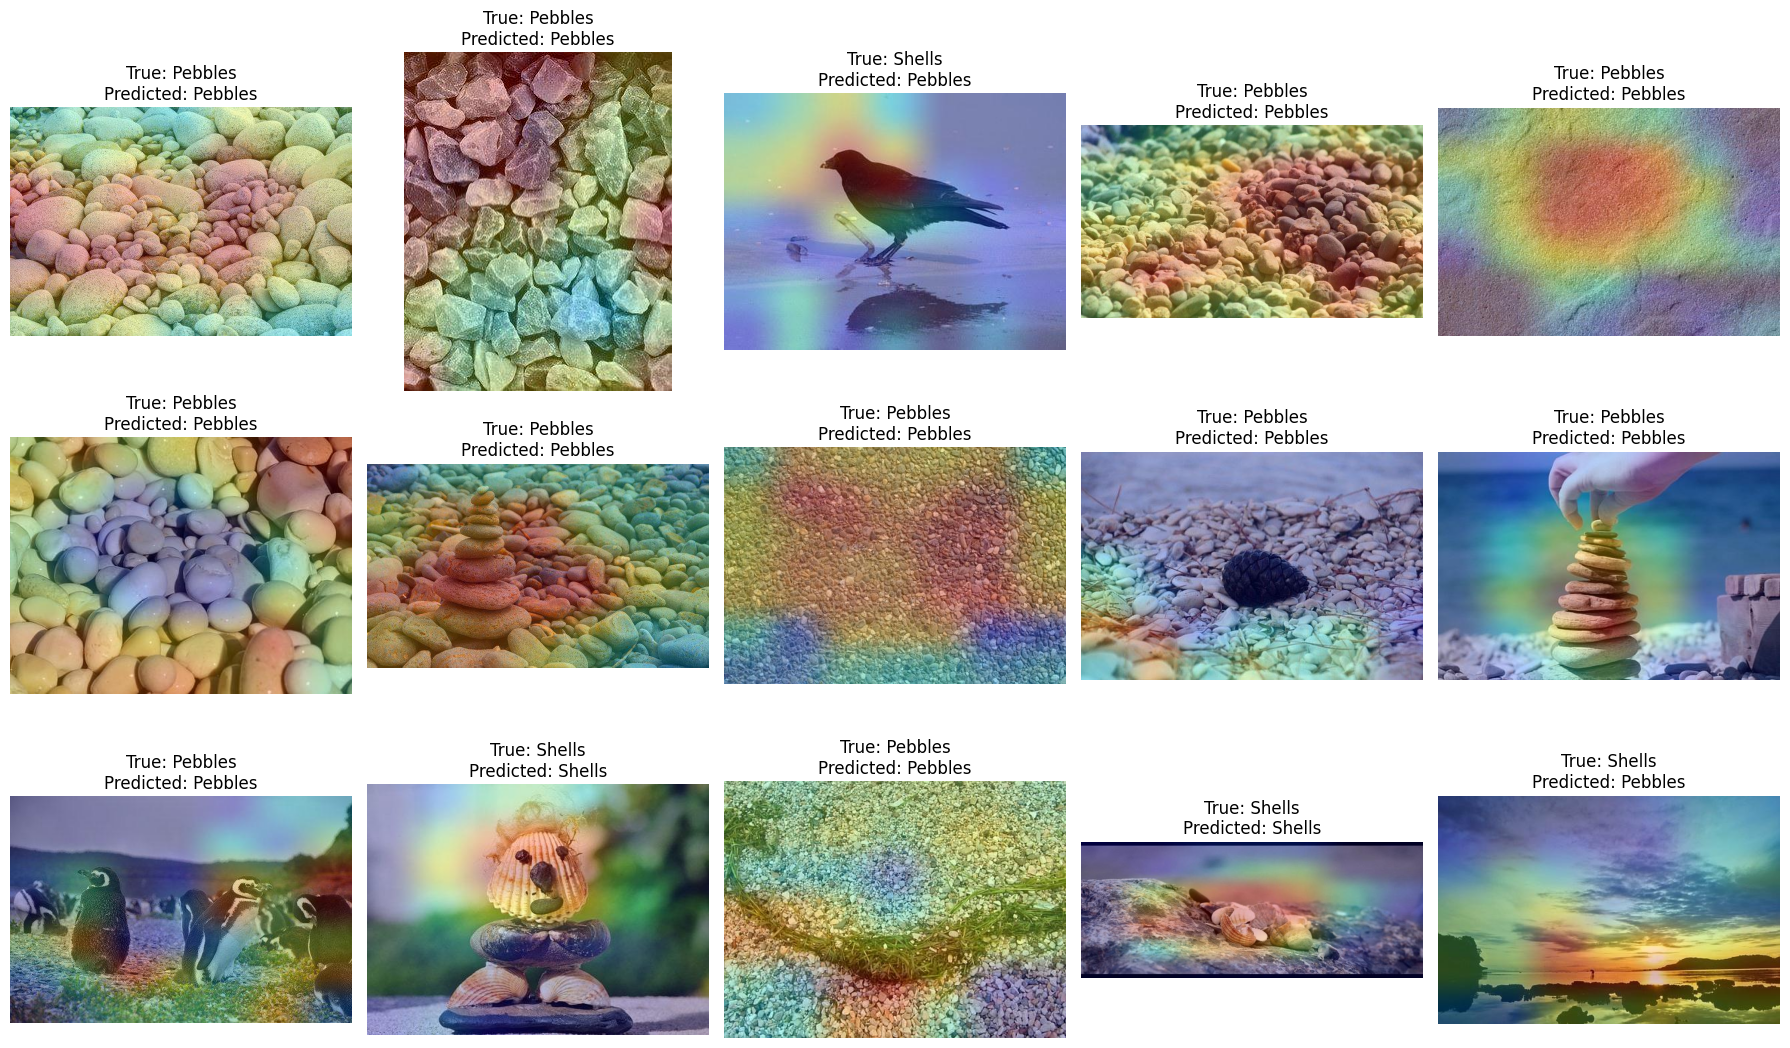

In [40]:
# Display Grad-CAM examples
random_index = np.random.choice(len(test_df), min(15, len(test_df)), replace=False)

fig, axes = plt.subplots(3, 5, figsize=(18, 11))

for i, ax in enumerate(axes.flat):
    if i < len(random_index):
        idx = random_index[i]
        img_path = test_df.iloc[idx]["Filepath"]

        img_array = tf.keras.applications.mobilenet_v2.preprocess_input(
            get_img_array(img_path, IMAGE_SIZE)
        )

        heatmap = make_gradcam_heatmap(
            img_array,
            model,
            pretrained_model,
            last_conv_layer_name
        )

        cam_path = save_and_display_gradcam(img_path, heatmap)
        ax.imshow(plt.imread(cam_path))
        ax.set_title(
            f"True: {test_df.iloc[idx]['Label']}\nPredicted: {pred_labels[idx]}"
        )

    ax.axis("off")

plt.tight_layout()
plt.show()
